# Аналитика данных с помощью `pandas` и `matplotlib`

В этом задании вам предлагается выполнить анализ данных криптовалют с помощью библиотек pandas и matplotlib.
Задание выглядит как лабораторная работа, в которой вам предстоит заполнить недостающие клетки и ответить на ряд вопросов.
 - [Официальная документация pandas](https://pandas.pydata.org/)
 - [Официальная документация matplotlib](https://matplotlib.org/index.html)

## Внимание! Attention! Achtung!

**Данная лабораторная работа является блокирующей**, т.е. если лабораторная работа не выполнена, то оценка за курс - неуд.

Лабораторная работа считается выполненной, если набран как минимум 1 балл.

## Формат сдачи лабораторной работы

Данная лабораторная работа сдается так же, как и проект:
- заполняете данный ноутбук
- создаете приватный репозиторий в GitHub
- добавляете в него проверяющего
- загружаете заполненный ноутбук в отдельную ветку
- создаете MR с указанием проверяющего

**Ассистенты не будут запускать ячейки кода, а смотреть на выведенный результат и код. Если ячейка кода не запущена - балл не ставится, даже при правильно написанном коде.**

## 1. Данные (2 балла)

Скачиваем данные для работы:

In [6]:
%%bash
gdown 1l-vkTaM1sK0g2jWHkwiFWDtWjCrac9uM

Downloading...
From: https://drive.google.com/uc?id=1l-vkTaM1sK0g2jWHkwiFWDtWjCrac9uM
To: /content/coins.csv
100%|██████████| 3.98M/3.98M [00:00<00:00, 203MB/s]


Начнем с необходимых приготовлений.

In [7]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import ipywidgets  # Библиотека для интерактивных контролов в jupyter notebook'е

%matplotlib inline

#### Загрузите заранее подготовленный датасет из файла `coins.csv`. Создайте объект типа `pandas.DataFrame` с именем `coins` и в качестве индекса выберите колонку с датой.

In [8]:
import pandas as pd

coins = pd.read_csv('coins.csv')

coins.set_index('date', inplace=True)


Посмотрим что получилось

In [9]:
coins.head(4)

,price,txCount,txVolume,activeAddresses,symbol,name,open,high,low,close,volume,market
date,,,,,,,,,,,,
2013-04-28,135.30,41702.0,6.879868e+07,117984.0,BTC,Bitcoin,135.30,135.98,132.10,134.21,0.0,1.500520e+09
2013-04-28,4.30,9174.0,4.431952e+07,17216.0,LTC,Litecoin,4.30,4.40,4.18,4.35,0.0,7.377340e+07
2013-04-29,134.44,51602.0,1.138128e+08,86925.0,BTC,Bitcoin,134.44,147.49,134.00,144.54,0.0,1.491160e+09
2013-04-29,4.37,9275.0,3.647810e+07,18395.0,LTC,Litecoin,4.37,4.57,4.23,4.38,0.0,7.495270e+07


Поясним значения хранящиеся в колонках
 - date - дата измерений
 - name - полное название монеты
 - symbol - сокращенное название монеты
 - price - средняя цена монеты за торговый день в USD
 - txCount - количество транзакций в сети данной монеты
 - txVolume - объем монет переведенных между адресами в сети данной монеты
 - activeAddresses - количество адресов совершавших а данный день транзации в сети данной монеты
 - open - цена монеты в начале торгов данного дня
 - close - цена монеты в конце торгов данного дня
 - high - самая высокая цена данной монеты в течение данного торгового дня
 - low - самая низкая цена данной монеты в течение данного торгового дня
 - volume - объем торгов данной монетой на биржах в данный день
 - market - капитализация данной монеты в данный день

Изучим полученные данные. Ответьте на следующие вопросы (вставляйте клетки с кодом и тектом ниже):

### 1. Сколько всего различных монет представлено в датасете? (0.4 балла)

In [10]:
num_coins = coins['name'].nunique()
num_coins

70

### 2. За какой период данные мы имеем? (0.4 балла)

In [11]:
df = pd.read_csv('coins.csv')

df['date'] = pd.to_datetime(df['date'])

start_date = df['date'].min()
end_date = df['date'].max()

formatted_start_date = start_date.strftime('%Y-%m-%d')
formatted_end_date = end_date.strftime('%Y-%m-%d')

print("Период данных:")
print("Начало:", formatted_start_date)
print("Конец:", formatted_end_date)


Период данных:
Начало: 2013-04-28
Конец: 2018-06-06


### 3. Есть ли пропуски в данных? Какой природы эти пропуски, чем они скорее всего вызваны? (0.5 балла)

In [12]:
missing_values = df.isnull().sum()

for column, value in missing_values.items():
  if value > 0:
    print(f"В столбце {column} пропусков {value}")


В столбце price пропусков 327
В столбце txCount пропусков 1520
В столбце txVolume пропусков 1830
В столбце activeAddresses пропусков 1520


В эти дни не было торговли данными монетами, поэтому и возникли пропуски

### 4. У какой монеты и когда была самая высокая цена? (0.2 балла)

In [13]:
max_high = coins['high'].max()
coin_highest_price = coins[coins['high'] == max_high]

print("Самая высокая цена у монеты:", coin_highest_price['name'].values[0])
print("Дата с самой высокой ценой:", coin_highest_price.index.values[0])


Самая высокая цена у монеты: Bitcoin
Дата с самой высокой ценой: 2017-12-17


### 5. У какой монеты самая высокая и самая низкая средняя капитализация (среднее арифметическое капитализаций за все доступные дни)? Постройте круговую диаграмму с долями. (0.5 балла)

Монета с самой высокой средней капитализацией: Bitcoin
Монета с самой низкой средней капитализацией: KingN Coin


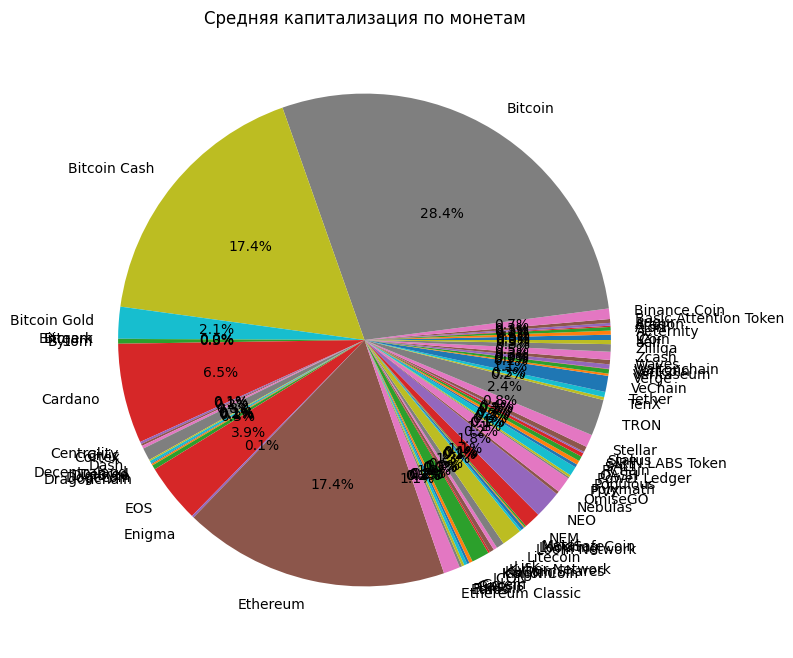

In [14]:
mean_capitalization = coins.groupby('name')['market'].mean()

max_cap_coin = mean_capitalization.idxmax()
min_cap_coin = mean_capitalization.idxmin()

print("Монета с самой высокой средней капитализацией:", max_cap_coin)
print("Монета с самой низкой средней капитализацией:", min_cap_coin)

plt.figure(figsize=(8, 8))
mean_capitalization.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Средняя капитализация по монетам')
plt.show()


## 2. Визуализация (1 балл)

Самая интересная часть работы аналитика состоит во внимательном вглядывании в правильно выбранные и построенные графики.

**Реализуйте функцию для визуализации цен выбранной валюты за выбранный диапазон дат.**

На графике должны быть видны цены начала и конца продаж. А так же минимальная и максимальная цена за этот день.
Подпишите график и оси координат. Добавьте сетку. Увеличьте размер изображения.
Можете попробовать использовать `candlestick_ohlc` (`from mplfinance.original_flavor import candlestick_ohlc`), но можно и без него.

In [15]:
import matplotlib.dates as mdates

def plot_fancy_price_action(coins, symbol, start_date, end_date):
    selected_coin = coins[coins['symbol'] == symbol]
    selected_date_range = selected_coin.loc[start_date:end_date]

    plt.figure(figsize=(12, 8))
    plt.plot(selected_date_range.index, selected_date_range['open'], label='Open', marker='o')
    plt.plot(selected_date_range.index, selected_date_range['close'], label='Close', marker='o')
    plt.scatter(selected_date_range.index, selected_date_range['high'], label='High', marker='^', color='green')
    plt.scatter(selected_date_range.index, selected_date_range['low'], label='Low', marker='v', color='red')

    plt.title(f'Price Action for {symbol} from {start_date} to {end_date}')
    plt.xlabel('Date')
    plt.ylabel('Price in USD')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.tight_layout()
    plt.show()


Посмотрим, что получилось:

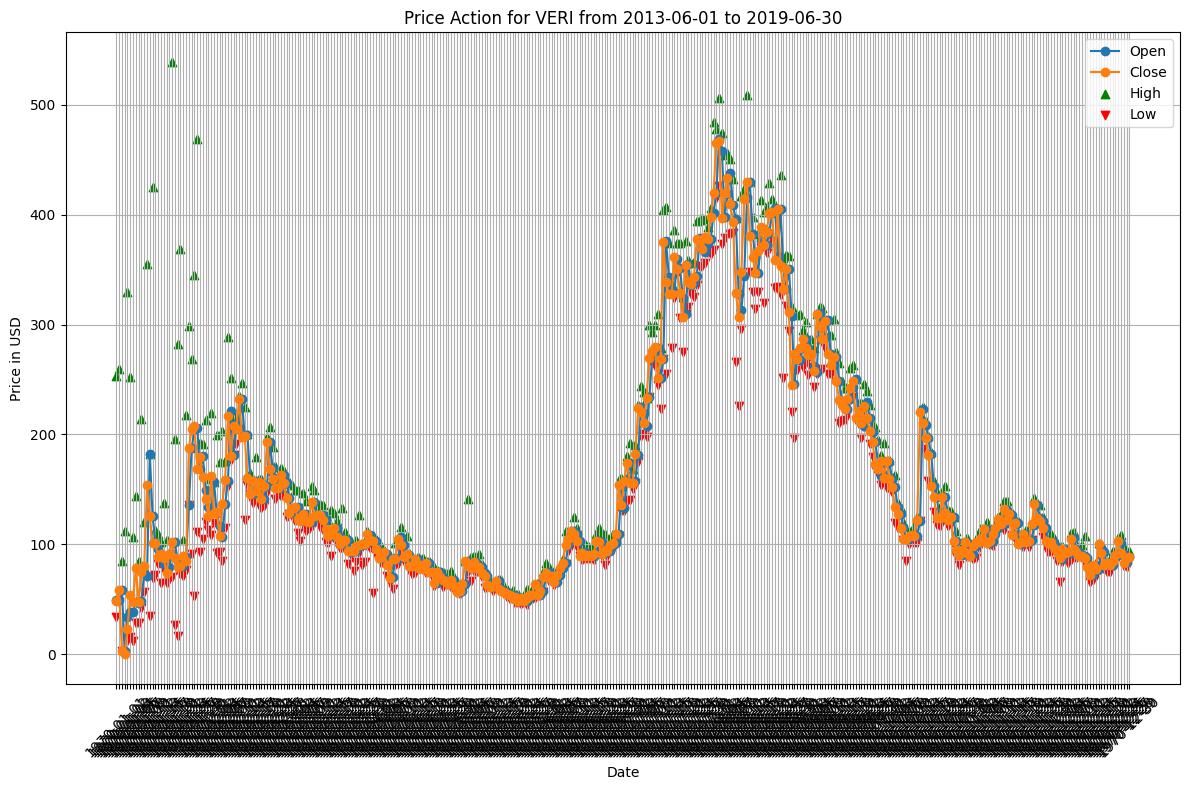

In [16]:
plot_fancy_price_action(coins=coins, symbol='VERI', start_date='2013-06-01', end_date='2019-06-30')

Никакого датасаенса в этом задании нет. Просто аналитик должен уметь строить графики, либо знать готовые инструменты.

## 3. Накачка и сброс (1 балл)

Криптовалютные биржи до сих пор остаются маргинальным местом, эдаким диким западом финансового мира. Как следствие, здесь процветают схемы относительно
честного отъема денег. Одна из них - **pump'n'dump** (накачка и сброс).

Она выглядит следуюшим образом. Несколько крупных игроков или много мелких договариваются вместе купить малоизвестную монету с низкой ценой и объемом торгов. Это приводит к мгновенному взлету цены (pump), далее приходят неопытные игроки в надежде успеть заработать на таком росте. В этот момент организаторы схемы начнают все продавать (dump). Весь процесс занимает от нескольких минут до нескольких часов.

Ваша задача -- **найти самый сильный pump'n'dump** монеты на заданном промежутке времени. Для этого для каждого дня определим число `pnd` равное отношению максимальной цены монеты в данный день к максимуму из цен открытия и закрытия в тот же день. Нужно найти день, когда `pnd` был максимален и величину `pnd`.

In [19]:
def find_most_severe_pump_and_dump(coins, symbol, start_date, end_date):
    selected_coin = coins[coins['symbol'] == symbol]  # Filter data for the selected cryptocurrency and dates
    selected_date_range = selected_coin.loc[start_date:end_date].copy()  # Create a copy to avoid SettingWithCopyWarning

    selected_date_range['pnd'] = selected_date_range['high'] / selected_date_range[['open', 'close']].max(axis=1)

    max_pnd_day = selected_date_range['pnd'].idxmax()
    max_pnd_value = selected_date_range.loc[max_pnd_day, 'pnd']

    return max_pnd_day, max_pnd_value


In [20]:
max_pnd_day, max_pnd_value = find_most_severe_pump_and_dump(coins, symbol='BTC', start_date='2017-06-01', end_date='2018-06-01')
print(f"The most severe pump'n'dump day for BTC: {max_pnd_day}, with a pnd value of {max_pnd_value}")

The most severe pump'n'dump day for BTC: 2017-11-29, with a pnd value of 1.1428940004366206


Сравните эти значения для разных монет:

In [21]:
pnd_BTC = find_most_severe_pump_and_dump(coins, symbol='BTC', start_date='2017-06-01', end_date='2018-06-01')
pnd_LTC = find_most_severe_pump_and_dump(coins, symbol='LTC', start_date='2017-06-01', end_date='2018-06-01')
pnd_DOGE = find_most_severe_pump_and_dump(coins, symbol='DOGE', start_date='2017-06-01', end_date='2018-06-01')
pnd_VTC = find_most_severe_pump_and_dump(coins, symbol='VTC', start_date='2017-06-01', end_date='2018-06-01')

print(f"BTC pnd: {pnd_BTC[1]}")
print(f"LTC pnd: {pnd_LTC[1]}")
print(f"DOGE pnd: {pnd_DOGE[1]}")
print(f"VTC pnd: {pnd_VTC[1]}")


BTC pnd: 1.1428940004366206
LTC pnd: 1.1082257158899496
DOGE pnd: 1.2747326203208558
VTC pnd: 1.3952095808383234


## 4. Окупаемость инвестиций (1 балл)

Вам нужно посчитать **окупаемость инвестиций (ROI)** в криптовалюты на заданном промежутке времени.

Окупаемость определяется как отношение *изменения цены портфеля* к *исходной цене портфеля*. Цена портфеля - это суммарная стоимость (в USD) всех монет в портфеле.

`investments` - словарь, в котором ключи - это названия монет, значения - это сумма вложений в эту монету (в USD).

In [22]:
def compute_roi(coins, investments, start_date, end_date):
    portfolio_value_start = {}
    portfolio_value_end = {}

    for coin, investment_amount in investments.items():
        selected_coin = coins[(coins['name'] == coin) & (coins.index == start_date)]
        if not selected_coin.empty:
            price_at_start = selected_coin.iloc[0]['close']
            portfolio_value_start[coin] = investment_amount / price_at_start
        else:
            print(f"No data available for {coin} on the start date: {start_date}")
            portfolio_value_start[coin] = 0

    for coin, investment_amount in investments.items():
        selected_coin = coins[(coins['name'] == coin) & (coins.index == end_date)]
        if not selected_coin.empty:
            price_at_end = selected_coin.iloc[0]['close']
            portfolio_value_end[coin] = portfolio_value_start[coin] * price_at_end
        else:
            print(f"No data available for {coin} on the end date: {end_date}")
            portfolio_value_end[coin] = 0

    # Вычисление ROI для каждой монеты
    roi = {}
    for coin in investments.keys():
        roi[coin] = (portfolio_value_end[coin] - investments[coin]) / investments[coin] if investments[coin] != 0 else 0

    return roi

In [23]:
compute_roi(coins, investments={'BTC': 1000, 'LTC': 500}, start_date='2018-04-04', end_date='2018-06-01')

No data available for BTC on the start date: 2018-04-04
No data available for LTC on the start date: 2018-04-04
No data available for BTC on the end date: 2018-06-01
No data available for LTC on the end date: 2018-06-01


{'BTC': -1.0, 'LTC': -1.0}

In [24]:
compute_roi(coins, investments={'BTC': 1000, 'LTC': 500}, start_date='2013-05-28', end_date='2018-06-06')

No data available for BTC on the start date: 2013-05-28
No data available for LTC on the start date: 2013-05-28
No data available for BTC on the end date: 2018-06-06
No data available for LTC on the end date: 2018-06-06


{'BTC': -1.0, 'LTC': -1.0}

## 5. Технический анализ (1 балл)

**Технический анализ** - это способ предсказания поведения графика по некоторым вспомогательным величинам построенным по исходному графику. Один из простейших методов технического анализа - **[границы Боллинджера](https://en.wikipedia.org/wiki/Bollinger_Bands)**. Кто-то верит, что график касаясь границы от него должен отражаться.

Границы считаются очень просто:

$$(MA \pm K\sigma),$$

где `MA` - скользящее среднее за `N` дней, а $\sigma$ - скользящее стандартное отклонение за `N` дней.

Нарисуйте **график цены**, **скользящее среднее** и **границы Боллинджера** c параметрами `N (window) = 21`, `K (width) = 2`.

Тут вам поможет функция `rolling` для подсчёта среднего и стандартного отклонения по скользящему окну.

Не забудьте подписать график и оси, отрисовать легенду и выбрать для нее лучшее расположение.

In [26]:
def plot_bollinger_bands(coins, symbol, window, width):
    selected_coin = coins[coins['symbol'] == symbol]

    # Рассчитываем скользящее среднее и стандартное отклонение
    selected_coin['MA'] = selected_coin['close'].rolling(window=window).mean()
    selected_coin['std'] = selected_coin['close'].rolling(window=window).std()

    # Рассчитываем границы Боллинджера
    selected_coin['upper_band'] = selected_coin['MA'] + width * selected_coin['std']
    selected_coin['lower_band'] = selected_coin['MA'] - width * selected_coin['std']

    # Строим график
    plt.figure(figsize=(12, 6))
    plt.plot(selected_coin.index, selected_coin['close'], label='Price', color='black')
    plt.plot(selected_coin.index, selected_coin['MA'], label=f'{window} Day MA', color='blue')
    plt.plot(selected_coin.index, selected_coin['upper_band'], label='Upper Bollinger Band', color='red', linestyle='--')
    plt.plot(selected_coin.index, selected_coin['lower_band'], label='Lower Bollinger Band', color='green', linestyle='--')

    plt.title(f'Bollinger Bands for {symbol}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend(loc='best')
    plt.grid(True)

    plt.show()

<ipython-input-26-24f88fae5b7d>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_coin['MA'] = selected_coin['close'].rolling(window=window).mean()
<ipython-input-26-24f88fae5b7d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_coin['std'] = selected_coin['close'].rolling(window=window).std()
<ipython-input-26-24f88fae5b7d>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

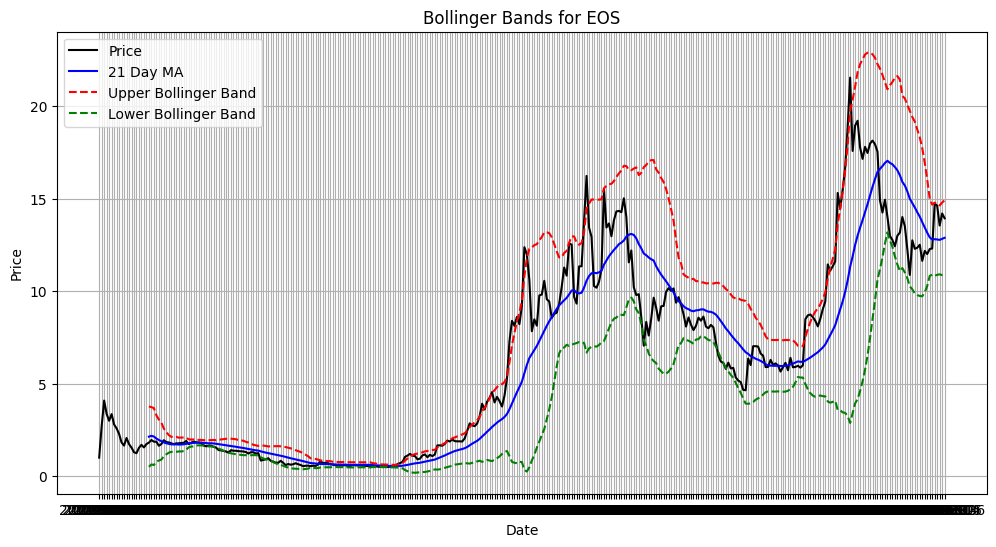

In [27]:
plot_bollinger_bands(coins=coins, symbol='EOS', window=21, width=2)  # тут должен появиться график

**Сделайте вывод о том, выполнялось ли правило Боллинджера:**

Цена в разные моменты времени касалась и пересекала как верхнюю, так и нижнюю полосы Боллинджера. Это указывает на значительную волатильность цены.
Полосы Боллинджера расширяются при увеличении волатильности и сужаются при ее снижении. Это видно на графике, где полосы Боллинджера охватывают линию цены, расширяясь и сужаясь в соответствии с изменениями волатильности.
Средняя скользящая за 21 день следует за трендом линии цены, но является более гладкой из-за усреднения.
Таким образом, на основании этих наблюдений, можно сказать, что правило Боллинджера выполнялось.

## 6. Капитализация как индикатор (1 балл)

Многие люди, которые торгуют криптовалютой, любят смотреть на [капитализацию](https://academy.binance.com/ru/articles/crypto-market-capitalization-explained). Давайте поймём почему.

**Нарисуйте еще два графика:**
1. общая капитализация биткойна (BTC), эфира (ETH), еос (EOS), биткойн кэша (BCH), стеллара (XLM) и лайткойна (LTC)
2. доли капитализаций этих монет от общей капитализации рынка.

При этом используйте данные начиная с 2017-07-01.

In [ ]:
def plot_coins_capitalizations(coins, symbols, start_date):
    # Paste your code here

In [ ]:
plot_coins_capitalizations(
    coins=coins,
    symbols=('BTC', 'ETH', 'EOS', 'BCH', 'XLM', 'LTC'),
    start_date='2017-07-01'
)

Проанализируйте зависимость доли капитализации альткойнов (остальных монет, кроме биткойна) от доли капитализации биткойна. Как выдумаете, в чём причина такой зависимости?

**Ваш ответ тут**

## 7. Корреляции монет (1 балл)

Теперь нужно подробнее посмотреть на корреляции средних долей капитализаций монет. При этом будем смотреть на среднее сглаженное за последние `window` дней до дня `date` с коэффициентом сглаживания `alpha` для набора монет `symbols`.

Реализуйте функцию, которая будет возвращать квадратный `DataFrame` с числом строк и столбцов, равным числу рассматриваемых монет и со значениями корреляций:

In [ ]:
def calc_coins_correlations(coins, date, symbols, window, alpha):
    # Paste your code here

In [ ]:
correlations = calc_coins_correlations(coins, date="2018-06-06",
                                       symbols=['BTC', 'ETH', 'EOS', 'BCH', 'XLM', 'LTC', 'ADA'],
                                       window=21, alpha=0.1)
# Теперь посмотрим на эти корреляции следующим образом:
correlations.style.background_gradient(cmap='coolwarm').set_precision(2)

Довольно интересно ещё взглянуть на 2017-12-27:

In [ ]:
correlations = calc_coins_correlations(coins, date="2017-12-27",
                                       symbols=['BTC', 'ETH', 'EOS', 'BCH', 'XLM', 'LTC', 'ADA'],
                                       window=21, alpha=0.1)
# Теперь посмотрим на эти корреляции следующим образом:
correlations.style.background_gradient(cmap='coolwarm').set_precision(2)

## 8. Анализ одной стратегии (2 балла)

Разберем один мечтательный пример. Посмотрим какую прибыль могла бы нам принести хрестоматийная торговая стратегия, основанная на скользящих средних.

Стратегия выглядит следующим образом: мы строим две скользящие среднии для графика цены. С маленьким окном (ведущее скользящее среднее) и с бОльшим окном (запаздывающее скользящее среднее). **Мы покупаем, когда ведущее среднее становится больше запаздывающего, и продаем в противном случае.**

Посмотрим на пример:

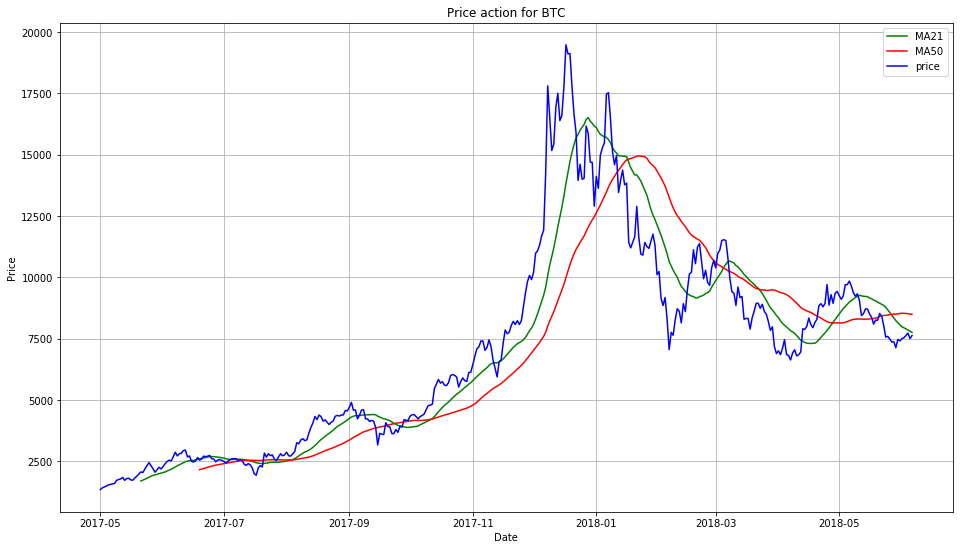

In [ ]:
def plot_moving_averages(coins, symbol, leading_window, lagging_window, start_date, end_date):
    coin = coins[coins['symbol'] == symbol][start_date:end_date]
    price = coin['price']
    leading_mean = price.rolling(window=leading_window).mean()
    lagging_mean = price.rolling(window=lagging_window).mean()

    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(111)

    ax.set_title('Price action for {}'.format(symbol))
    ax.plot(leading_mean, color='green', label='MA{}'.format(leading_window))
    ax.plot(lagging_mean, color='red', label='MA{}'.format(lagging_window))
    ax.plot(price, color='blue', label='price')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend(loc='best')
    ax.grid(True)
    plt.show()

plot_moving_averages(
    coins=coins,
    symbol='BTC',
    leading_window=21,
    lagging_window=50,
    start_date='2017-05-01',
    end_date='2018-08-01')

Видно, что скользящее среднее с бОльшим окном медленнее реагирует на изменение цены. Именно на этой идее и основана торговая стратегия/


**Реализуйте функцию**, которая строит два графика. На правом будут изображены цена и скользящие средние. На левом - во сколько раз изменится размер вложений при использовании нашей стратегии и при обычном инвестировании (купили и держим, смотрим как растет цена наших купленных валют).

Иными словами сравниваем 2 подхода:
- сразу в начальный момент времени купить крипты на все деньги - обычное инвестирование
- ждать подходящих моментов и покупать только в них равными порциями - стратегия

Считайте, что суммарное количество вложенных денег в обоих подходах одинаковое.

>**Примечания:**
>- Давайте использовать только цены закрытия. При этом, чтобы узнать цены за вчерашний день, стоит использовать метод `shift(1)` у `Series`.
>- Отношение цен закрытия за сегодня и за вчера - это **multiplier** за сегодняшний день. При этом давайте строить графики накопления для multiplier-ов. Т.е. если мы смотрим на 3 дня и в первый день multiplier = 1.5, во второй - 0.5 и в третий - 2, то график будет выглядеть так: (1.5, 1.5 * 0.5, 1.5 * 0.5 * 2).
>- При использовании нашей новой стратегии мы будем либо покупать, если ведущее среднее становится больше запаздующего на некоторый `threshold` (при этом лучше разницу сперва поделить на цену), либо оставлять всё как есть. При этом, конечно, нужно, принимая решения за сегодняшний день, смотреть только на статистику из прошлого.

In [ ]:
def plot_moving_averages_strategy(
    coins, symbol, lead_window, lag_window, threshold, start_date, end_date
):
    # Paste your code here

In [ ]:
# Теперь на основе реализованной функции сделаем интерактивные графики и поизучаем, что получилось:
symbol_selector = ipywidgets.Dropdown(
    options=('BTC', 'ETH', 'EOS', 'BCH', 'XLM', 'LTC', 'ADA'),
    index=0,
    value='BTC',
    layout={'width': '700px'},
    continuous_update=False
)

lead_window_slider = ipywidgets.IntSlider(
    value=21,
    min=1,
    max=200,
    step=1,
    layout={'width': '700px'},
    continuous_update=False)

lag_window_slider = ipywidgets.IntSlider(
    value=50,
    min=1,
    max=200,
    layout={'width': '700px'},
    step=1, continuous_update=False)

threshold_slider = ipywidgets.FloatSlider(
    min=0,
    max=0.20,
    step=0.001,
    value=0.025,
    layout={'width': '700px'},
    continuous_update=False)

start_date_slider = ipywidgets.SelectionSlider(
    options=pd.date_range('2013-04-28', '2018-06-06', freq='D'),
    index=0,
    value=pd.Timestamp('2017-05-01'),
    layout={'width': '700px'},
    continuous_update=False
)

end_date_slider = ipywidgets.SelectionSlider(
    options=pd.date_range('2013-04-28', '2018-06-06', freq='D'),
    index=0,
    value=pd.Timestamp('2018-01-01'),
    layout={'width': '700px'},
    continuous_update=False
)

ipywidgets.interact(
    plot_moving_averages_strategy,
    coins=ipywidgets.fixed(coins),
    symbol=symbol_selector,
    lead_window=lead_window_slider,
    lag_window=lag_window_slider,
    threshold=threshold_slider,
    start_date=start_date_slider,
    end_date=end_date_slider
)

Попробуйте разные значения параметров для разных монет и сделайте выводы о применимости такой модели:

**Ваш ответ тут**

## 9. Отказ от ответственности

Все примеры разобранных здесь стратегий являются игрушечными и не подходят для реальной торговли на бирже. Без серьезной подготовки вас там съедят с потрохами.